Goal: train NeuralODE with fixed interval on test images with fixed variance gaussian noise.

In [1]:
using Pkg
Pkg.activate("../../")
Pkg.instantiate()

  Activating project at `~/Code/Julia/ImplicitDenoiser`


In [2]:
im_path = "../../../Images/128/"

"../../../Images/128/"

In [3]:
using Lux, LuxCUDA, MLUtils
using Optimisers, Random, Statistics
using Zygote
using DiffEqFlux, OrdinaryDiffEq
using FFTW
#using Reactant
using Images, JLD2
using ComponentArrays
using DeepEquilibriumNetworks
using Plots
using Dates

In [4]:
#Reactant.set_default_backend("cpu")
#const device = reactant_device()
const cdev = cpu_device()
const gdev = gpu_device()
dev = gdev

(::CUDADevice{Nothing, Missing}) (generic function with 1 method)

In [16]:
model_conv = Chain(
            Conv((5, 5), 1 => 8, gelu; pad = 2),
            Conv((5, 5), 8 => 16, gelu; pad = 2),
        Conv((1, 1), 16 => 64, tanh),
        Conv((1, 1), 64 => 32, tanh),
        Conv((1, 1), 32 => 1),
    ) 


Chain(
    layer_1 = Conv((5, 5), 1 => 8, gelu_tanh, pad=2),  # 208 parameters
    layer_2 = Conv((5, 5), 8 => 16, gelu_tanh, pad=2),  # 3_216 parameters
    layer_3 = Conv((1, 1), 16 => 64, tanh),       # 1_088 parameters
    layer_4 = Conv((1, 1), 64 => 32, tanh),       # 2_080 parameters
    layer_5 = Conv((1, 1), 32 => 1),              # 33 parameters
)         # Total: 6_625 parameters,
          #        plus 0 states.

In [47]:
#model = NeuralODE(model_conv, (0.0f0, 1.0f0), Tsit5(); save_everystep = false,
#    sensealg = BacksolveAdjoint(; autojacvec = ZygoteVJP()),
#    reltol = 1e-5, abstol = 1e-6, save_start = false)
model = NeuralODE(model_conv, (0.0f0, 1.0f0), Tsit5(); save_everystep = false,
    sensealg = BacksolveAdjoint(; autojacvec = ZygoteVJP()),
    reltol = 1e-5, abstol = 1e-6, save_start = false)

NeuralODE(
    model = Chain(
        layer_1 = Conv((5, 5), 1 => 8, gelu_tanh, pad=2),  # 208 parameters
        layer_2 = Conv((5, 5), 8 => 16, gelu_tanh, pad=2),  # 3_216 parameters
        layer_3 = Conv((1, 1), 16 => 64, tanh),   # 1_088 parameters
        layer_4 = Conv((1, 1), 64 => 32, tanh),   # 2_080 parameters
        layer_5 = Conv((1, 1), 32 => 1),          # 33 parameters
    ),
)         # Total: 6_625 parameters,
          #        plus 0 states.

In [48]:
rng = Xoshiro(0)
_, st = Lux.setup(rng, model)

((layer_1 = (weight = Float32[-0.30580238 0.18938486 … 0.33024654 0.12650087; -0.031011743 -0.26833618 … 0.25797793 -0.2773095; … ; 0.03300763 -0.06136041 … 0.07961983 -0.18696542; 0.12824844 -0.32586965 … 0.11916554 0.18865287;;;; 0.09093706 3.0558529f-6 … -0.19399974 0.021667441; -0.111984864 -0.020606318 … 0.12386206 0.15174432; … ; 0.21957335 -0.2668298 … 0.23292983 0.06296065; 0.13718541 -0.026979052 … 0.04520965 -0.05915359;;;; 0.25620753 0.0105199795 … -0.06364512 -0.14203967; -0.07936133 -0.21008675 … -0.036428407 -0.32864538; … ; -0.18309778 0.22447027 … -0.2649486 0.30478093; 0.30851713 0.10652034 … -0.2563771 0.08460723;;;; 0.06988987 -0.12302083 … 0.1797195 -0.084307514; -0.13215667 -0.06367559 … -0.1801825 -0.32524836; … ; -0.21732795 0.16682376 … 0.18481661 0.22907941; -0.16016795 0.1763368 … 0.31328383 -0.27067426;;;; -0.12116444 0.28295907 … 0.15405698 -0.001604777; 0.22731717 0.089358136 … 0.21253197 0.016441934; … ; -0.2766099 -0.13225459 … 0.22571252 0.34452435; -0.0

In [19]:
#@load "st4.jld2" st
#@load "ps4.jld2" ps

In [49]:
#ps = ps |> ComponentArray |> dev
st = st |> dev

(layer_1 = NamedTuple(), layer_2 = NamedTuple(), layer_3 = NamedTuple(), layer_4 = NamedTuple(), layer_5 = NamedTuple())

In [50]:
opt = Optimisers.NAdam(1e-3)
state = Optimisers.setup(opt,ps)
train_state = Lux.Training.TrainState(model, ps, st, opt)

TrainState(
    NeuralODE(
        model = Chain(
            layer_1 = Conv((5, 5), 1 => 8, gelu_tanh, pad=2),  # 208 parameters
            layer_2 = Conv((5, 5), 8 => 16, gelu_tanh, pad=2),  # 3_216 parameters
            layer_3 = Conv((1, 1), 16 => 64, tanh),  # 1_088 parameters
            layer_4 = Conv((1, 1), 64 => 32, tanh),  # 2_080 parameters
            layer_5 = Conv((1, 1), 32 => 1),      # 33 parameters
        ),
    ),
    number of parameters: 6625
    number of states: 0
    optimizer: NAdam(eta=0.001, beta=(0.9, 0.999), epsilon=1.0e-8)
    step: 0
)


In [22]:
function loss_function(model, ps, st, (x, y_true))
    y_pred = model(x, ps, st)[1][1]
    loss_mse= MSELoss()
    mse_loss = loss_mse(y_pred, y_true)
    #sptrl_loss = loss_mse(dct(dct(y_pred,1),2),dct(dct(y_pred,1),2))
    return mse_loss, st
    #return mes_loss + sptrl_loss, st
end

loss_function (generic function with 1 method)

In [23]:
# This is to test the model if it works:
x = randn(Float32,128,128,1,4)
y_true = randn(Float32,128,128,1,4)
x_dev = x |> dev
y_dev = y_true |> dev
y, _ = model(x_dev, ps, st)

(ODESolution{Float32, 5, Vector{CuArray{Float32, 4, CUDA.DeviceMemory}}, Nothing, Nothing, Vector{Float32}, Vector{Vector{CuArray{Float32, 4, CUDA.DeviceMemory}}}, Nothing, ODEProblem{CuArray{Float32, 4, CUDA.DeviceMemory}, Tuple{Float32, Float32}, false, ComponentVector{Float32, CuArray{Float32, 1, CUDA.DeviceMemory}, Tuple{ComponentArrays.Axis{(layer_1 = ViewAxis(1:208, Axis(weight = ViewAxis(1:200, ShapedAxis((5, 5, 1, 8))), bias = ViewAxis(201:208, Shaped1DAxis((8,))))), layer_2 = ViewAxis(209:3424, Axis(weight = ViewAxis(1:3200, ShapedAxis((5, 5, 8, 16))), bias = ViewAxis(3201:3216, Shaped1DAxis((16,))))), layer_3 = ViewAxis(3425:4512, Axis(weight = ViewAxis(1:1024, ShapedAxis((1, 1, 16, 64))), bias = ViewAxis(1025:1088, Shaped1DAxis((64,))))), layer_4 = ViewAxis(4513:6592, Axis(weight = ViewAxis(1:2048, ShapedAxis((1, 1, 64, 32))), bias = ViewAxis(2049:2080, Shaped1DAxis((32,))))), layer_5 = ViewAxis(6593:6625, Axis(weight = ViewAxis(1:32, ShapedAxis((1, 1, 32, 1))), bias = ViewA

In [24]:
loss_function(model,ps,st,(x_dev,y_dev))
(loss, st), back = Zygote.pullback(ps -> loss_function(model, ps, st, (x_dev, y_dev)), ps)
grads = back((one(loss), nothing))[1]
state, ps = Optimisers.update(state, ps, grads)
train_state = Lux.Training.TrainState(model, ps, st, opt)

println("Loss: ", loss)

Loss: 2.1776829


In [25]:
function add_gaussian_noise(img, σ = 1e-3 )
    out = img .+ σ .* randn(eltype(img), size(img))
    if rand(Bool)
        @. out = min(max(out, 0.0),1.0) 
    end
    out
end

add_gaussian_noise (generic function with 2 methods)

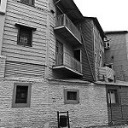

In [26]:
img = load(im_path * "1.jpg")

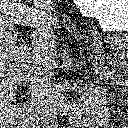

In [27]:
Gray.(add_gaussian_noise(Float32.(img), 4e-1))

In [28]:
function load_images_to_array(path,num,corrupt_func)
    x = zeros(Float32,128,128,1,num)
    y = zeros(Float32,128,128,1,num)
    for i in 1:num
        img = Float32.(load("$path$i.jpg"))
        #x[:,:,1,i] = Float32.(outdict["array"])
        #y[:,:,1,i] = Float32.(outdict["original"])
        x[:,:,1,i] = corrupt_func(img)
        y[:,:,1,i] = img
    end
    return x,y
end

load_images_to_array (generic function with 1 method)

In [29]:
cfunc(img) = add_gaussian_noise(Float32.(img),2e-1)

cfunc (generic function with 1 method)

In [30]:
X, Y = load_images_to_array(im_path,7000, cfunc)

(Float32[-0.3125273 0.8528542 … 0.8843579 0.99390775; 0.13384084 0.45942912 … 0.8308979 0.83217925; … ; 0.65060407 0.5894633 … 0.26156414 0.83050305; 0.59151584 0.9376002 … 0.5689467 0.78653806;;;; 0.4863675 0.7506088 … 0.60872614 0.5457535; 0.08519267 0.20448118 … 0.61865497 0.53968894; … ; 0.22314933 0.18770956 … 0.21699081 0.11953707; 0.18946107 0.025136188 … 0.05650764 0.24951226;;;; -0.17603126 0.14715593 … -0.17446887 0.08496716; -0.13177653 0.0068785935 … -0.04691454 -0.2788511; … ; 0.55879945 0.37663504 … 0.14017205 0.34604174; 0.34750763 0.7091701 … 0.049685307 0.07718814;;;; … ;;;; 0.44555366 0.14728901 … 0.055845324 0.68307996; 0.41640124 0.2715914 … 0.27151603 0.007748452; … ; 0.026325706 0.36404604 … 0.744802 0.6461177; 0.0 0.0 … 0.6828379 0.8031402;;;; -0.120838076 -0.16718246 … 0.89245963 0.07872142; 0.15287577 0.18466792 … 0.56624687 0.4154236; … ; 0.30132255 -0.011127135 … 0.16872694 0.08813674; -0.19536617 -0.055828076 … -0.18559875 -0.2546617;;;; 0.800594 0.6438312 …

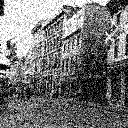

In [45]:
Gray.(X[:,:,1,3])

In [32]:
function load_images(batchsize, path, num, corrupt_func)
    x_img,y_img = load_images_to_array(path,num, corrupt_func)
    DataLoader(mapobs(gdev, (x_img, y_img)); batchsize, shuffle = true)
end

load_images (generic function with 1 method)

In [51]:
dataloader = load_images(64, im_path, 7000, cfunc)

110-element DataLoader(::MLUtils.MappedData{:auto, CUDADevice{Nothing, Missing}, Tuple{Array{Float32, 4}, Array{Float32, 4}}}, shuffle=true, batchsize=64)
  with first element:
  (128×128×1×64 CuArray{Float32, 4, CUDA.DeviceMemory}, 128×128×1×64 CuArray{Float32, 4, CUDA.DeviceMemory},)

In [52]:
# 📚 Training Parameters (use the values you set previously)
epochs = 5
losses = Float32[]
num_batches = length(dataloader)

println("Starting Training for $epochs epochs...")

# 🏁 Main Training Loop
for epoch in 1:epochs
    epoch_loss = 0.0f0
    
    # Iterate over all batches
    for (i, data) in enumerate(dataloader)
        # Perform the training step
        (loss, st), back = Zygote.pullback(ps -> loss_function(model, ps, st, data), ps)
        grads = back((one(loss), nothing))[1]
        state, ps = Optimisers.update(state, ps, grads)
        train_state = Lux.Training.TrainState(model, ps, st, opt)
        # Accumulate loss for the epoch
        epoch_loss += loss
        push!(losses, loss) # Store individual batch loss
        
        # Print progress
        if i % 10 == 0 # Print every 10 batches
            end_time = now()
            println("Epoch: $epoch/$epochs | Batch: $i/$num_batches | Loss: $loss | Time: $end_time")
        end
    end
    end_time = now()
    # Calculate and print average epoch loss
    avg_epoch_loss = epoch_loss / num_batches
    @save "ps$epoch$avg_epoch_loss$end_time.jld2" ps
    @save "st$epoch $avg_epoch_loss $end_time.jld2" st
    println("--- Epoch $epoch Finished! Average Loss: $avg_epoch_loss ---")
end

Starting Training for 5 epochs...
Epoch: 1/5 | Batch: 10/110 | Loss: 0.0073718526 | Time: 2026-01-06T22:51:36.932
Epoch: 1/5 | Batch: 20/110 | Loss: 0.0071074613 | Time: 2026-01-06T22:52:54.694
Epoch: 1/5 | Batch: 30/110 | Loss: 0.0073691327 | Time: 2026-01-06T22:54:12.879
Epoch: 1/5 | Batch: 40/110 | Loss: 0.0066559296 | Time: 2026-01-06T22:55:31.225
Epoch: 1/5 | Batch: 50/110 | Loss: 0.0072839526 | Time: 2026-01-06T22:56:48.438
Epoch: 1/5 | Batch: 60/110 | Loss: 0.0071231285 | Time: 2026-01-06T22:58:06.468
Epoch: 1/5 | Batch: 70/110 | Loss: 0.0072307573 | Time: 2026-01-06T22:59:24.673
Epoch: 1/5 | Batch: 80/110 | Loss: 0.0072225737 | Time: 2026-01-06T23:00:43.619
Epoch: 1/5 | Batch: 90/110 | Loss: 0.006512702 | Time: 2026-01-06T23:02:02.763
Epoch: 1/5 | Batch: 100/110 | Loss: 0.006607971 | Time: 2026-01-06T23:03:22.581
Epoch: 1/5 | Batch: 110/110 | Loss: 0.0063328953 | Time: 2026-01-06T23:04:37.110
--- Epoch 1 Finished! Average Loss: 0.008461141 ---
Epoch: 2/5 | Batch: 10/110 | Loss:

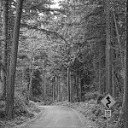

In [59]:
img_load = load(im_path*"6000.jpg")

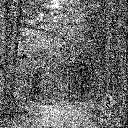

In [60]:
crrptd_img = cfunc(img_load)

Gray.(max.(0.0,min.(1.0,crrptd_img)))

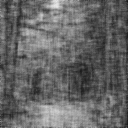

In [61]:
test_vec = zeros(Float32,128,128,1,10)
test_vec[:,:,1,1] = Float32.(crrptd_img)
y, _ = model(test_vec |> dev, ps, st)
recon_img = Gray.(min.(max.(Array(y)[:,:,1,1,1], 0.0),1.0))
recon_img

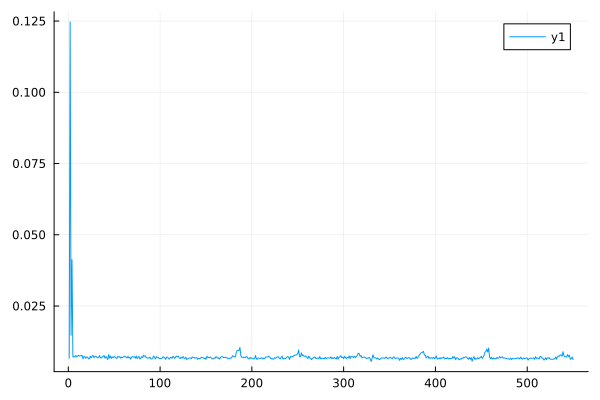

In [62]:
plot(losses)